# Per-Individual Statistics (Plots)

*29.09.2025*

This script attempts to:
1. plot the coverage per individual (from the “~ref/samples_coverage_stats.txt file”) ✅
2. plot the individual heterozygosity (calculated as number of SNPs divided by number of callable sites)

### Libraries

In [1]:
import os
species = "Elephas_maximus"
genus = species.split("_")[0]
if os.getcwd().startswith("/home/lakrids"):
    path_prefix = "/home/lakrids/GenomeDK"
else:
    path_prefix = "/faststorage/project/"

In [2]:
import pickle
with open(f"{path_prefix}/megaFauna/sa_megafauna/data/{species}/ref/parameters_{species}.pkl", "rb") as file:
    parameters = pickle.load(file)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotnine import ggplot, aes, geom_point, scale_x_log10, scale_y_continuous, scale_color_manual, labs, theme_bw, theme, element_text
import matplotlib.gridspec as gridspec

### File Input & First Data Impression

In [11]:
genus = "Boselaphus_tragocamelus"
data            = pd.read_table(f"{path_prefix}/megaFauna/sa_megafauna/metadata/samples_{genus}.txt")
ref_folder     = list(data.REFERENCE_FOLDER)[0] # list of references needed to map the SRR accessions
inds_to_include = list(data.loc[data.FOLDER == genus]["IND_ID"].drop_duplicates())
print(ref_folder)
print(inds_to_include)

Tragelaphus_eurycerus_isaaci
['LIB112678', 'LIB112679', 'LIB112680', 'LIB112681', 'LIB112682', 'LIB112683', 'LIB19620', 'LIB19621']


In [5]:
df_regions = pd.read_table(f"{path_prefix}/megaFauna/sa_megafauna/data/{ref_folder}/ref/regions_{ref_folder}_updated.txt")

In [6]:
df_samples = pd.read_table(f"{path_prefix}/megaFauna/sa_megafauna/metadata/samples_{genus}.txt")

In [7]:
df_coverage = pd.read_table(f"{path_prefix}/megaFauna/sa_megafauna/data/{ref_folder}/ref/samples_coverage_stats.txt", delimiter="\t")
df_coverage = df_coverage[df_coverage.IND_ID.isin(inds_to_include)]
# edit dataframe so we have cov_A >= 10 and cov_len_A >= 0.95 --> these will get a true in the "cov_filter" column
df_coverage['cov_filter'] = (df_coverage['cov_A'] >= 10) & (df_coverage['cov_len_A'] >= 0.90)
df_coverage

,IND_ID,length_A,sequenced_A,len_covered_raw_A,cov_A,cov_len_A,SEX,length_X,sequenced_X,len_covered_raw_X,cov_X,cov_len_X,rel_X_cov,gSEX,length_Y,sequenced_Y,len_covered_raw_Y,cov_Y,cov_len_Y,cov_filter
0,SAMD00195598,3199039572,2.741918e+11,3188148349,86.003,0.997,Unknown,181417049,8.309614e+09,180358920,46.073,0.994,0.536,M,15906473,1.061222e+09,14945063,71.008,0.940,True
1,SAMEA120295678,3199039572,7.356493e+10,3169745526,23.208,0.991,Unknown,181417049,4.086231e+09,180014465,22.699,0.992,0.978,F,15906473,1.971326e+06,462820,4.259,0.029,True
2,SAMEA120295679,3199039572,7.843806e+10,3169383347,24.749,0.991,Unknown,181417049,4.344075e+09,180135702,24.116,0.993,0.974,F,15906473,1.699476e+06,203995,8.331,0.013,True
3,SAMEA120295681,3199039572,7.488005e+10,3169153958,23.628,0.991,Unknown,181417049,4.175696e+09,179879970,23.214,0.992,0.982,F,15906473,1.463450e+06,205498,7.121,0.013,True
4,SAMEA120295682,3199039572,7.657690e+10,3179184916,24.087,0.994,Unknown,181417049,2.265784e+09,179803215,12.601,0.991,0.523,M,15906473,2.829523e+08,14922831,18.961,0.938,True
5,SAMEA120295683,3199039572,9.305367e+10,3173269435,29.324,0.992,Unknown,181417049,5.175474e+09,180327171,28.700,0.994,0.979,F,15906473,2.002760e+06,224837,8.908,0.014,True
6,SAMEA120295684,3199039572,7.546345e+10,3181408765,23.720,0.994,Unknown,181417049,2.261387e+09,179975304,12.565,0.992,0.530,M,15906473,2.795639e+08,14928080,18.727,0.938,True
7,SAMEA120295685,3199039572,6.954124e+10,3171041919,21.930,0.991,Unknown,181417049,3.885980e+09,180147930,21.571,0.993,0.984,F,15906473,1.530940e+06,195251,7.841,0.012,True
8,SAMEA120295686,3199039572,8.795303e+10,3178077936,27.675,0.993,Unknown,181417049,4.835845e+09,180199652,26.836,0.993,0.970,F,15906473,2.059677e+06,398473,5.169,0.025,True
9,SAMEA120295687,3199039572,7.233969e+10,3172270678,22.804,0.992,Unknown,181417049,4.003132e+09,180267465,22.207,0.994,0.974,F,15906473,1.688569e+06,351610,4.802,0.022,True


In [47]:
df_coverage_filtered = df_coverage[df_coverage["cov_filter"] == True]


### Coverage per Individual

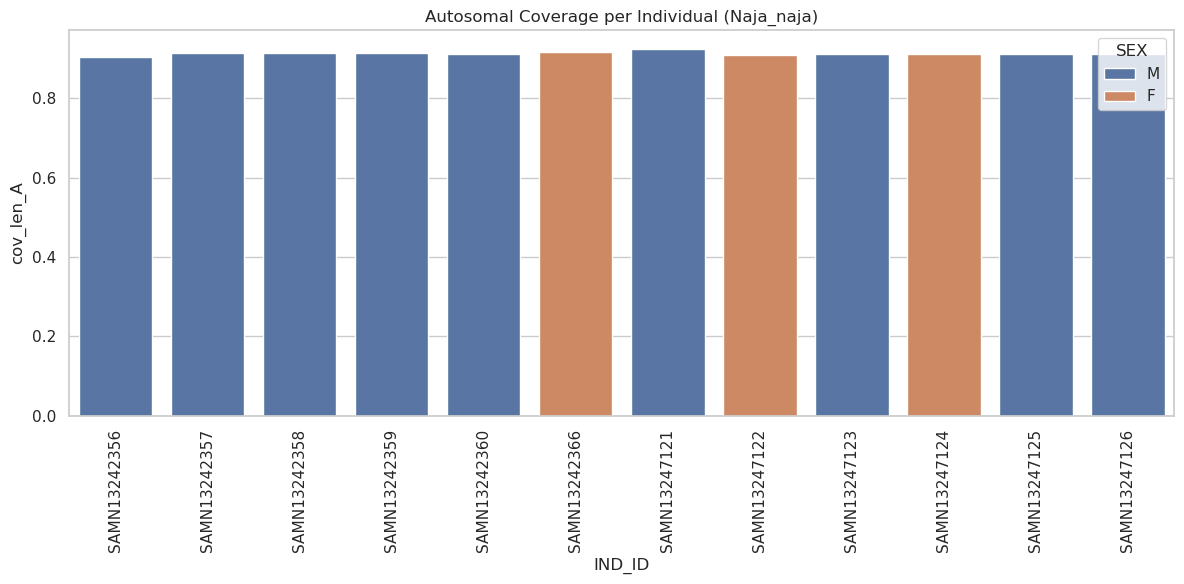

In [48]:
# add grid
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_coverage_filtered, x='IND_ID', y='cov_len_A', hue='SEX')
plt.xticks(rotation=90)
plt.title(f'Autosomal Coverage per Individual ({species})')
plt.tight_layout()
plt.show()

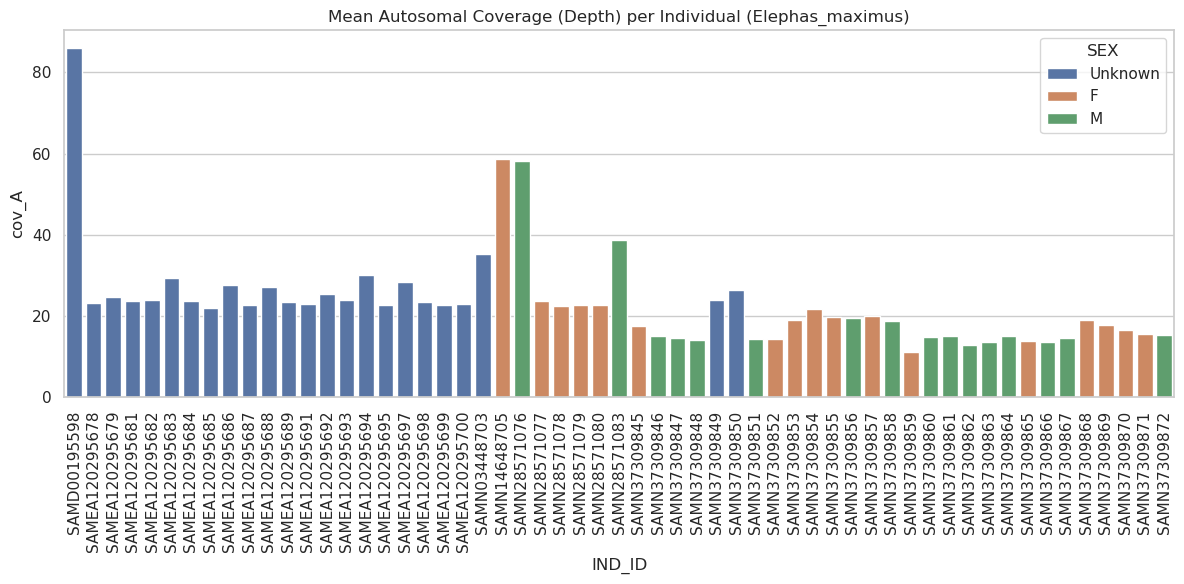

In [13]:
# add grid
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_coverage_filtered, x='IND_ID', y='cov_A', hue='SEX')
plt.xticks(rotation=90)
plt.title(f'Mean Autosomal Coverage (Depth) per Individual ({species})')
plt.tight_layout()
plt.show()

Just for me.<br>
So `cov_len_A` is the fraction of the genome that is covered. This is not about how deep the coverage is but if a base was covered at all. Values close to 1 mean, that nearly the entire genome is touched by sequencing. This is the case for all of the individuals.<br>
On the other hand, `cov_A` is how many reads, on average, cover each base in the autosomal genome. This reflects the sequencing depth. Lower values mean fewer reads per base which might suggests noisy or unreliable data.<br>

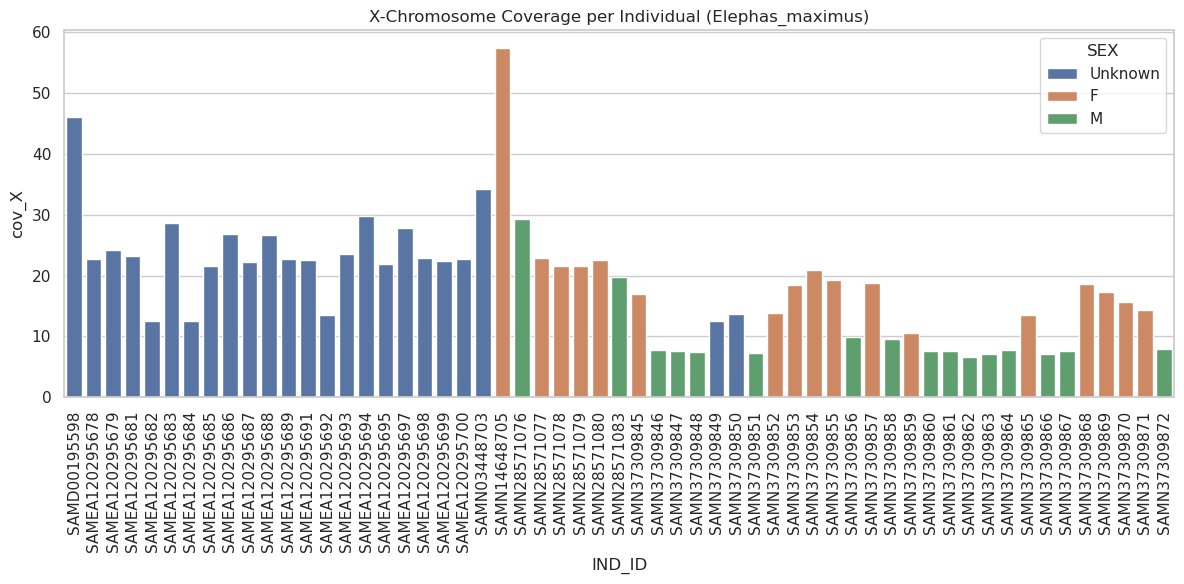

In [14]:
# add grid
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_coverage_filtered, x='IND_ID', y='cov_X', hue='SEX')
plt.xticks(rotation=90)
plt.title(f'X-Chromosome Coverage per Individual ({species})')
plt.tight_layout()
plt.show()

### Individual Heteroyzgosity

Maybe do filtering first? <br>
Also, how do we want to process the files - we do have quite a lot.

# Figure 1: Coverage

R script for this can be found [here](https://github.com/Bjarke-M/Primate-Recalling/blob/main/plots/figure1/Figure1_coverage.ipynb). Script was converted to Python via Copilot. <br>
This creates a coverage plot which plots the average coverage over the whole genome against the covered fraction of the genome. Tthis plot also visualizes, which samples are good and which ones aren't.

### Plot style and layout

#### Plotting instructions
Be careful when choosing the cutoffs. Check single plots and see in which intervalls we have datapoints. Choose cutoffs for scatterplot and then make sure with `set_xlim` and `set_ylim` arguments that the histograms at the side actually match with the scales! Otherwise the scale will be wrong!

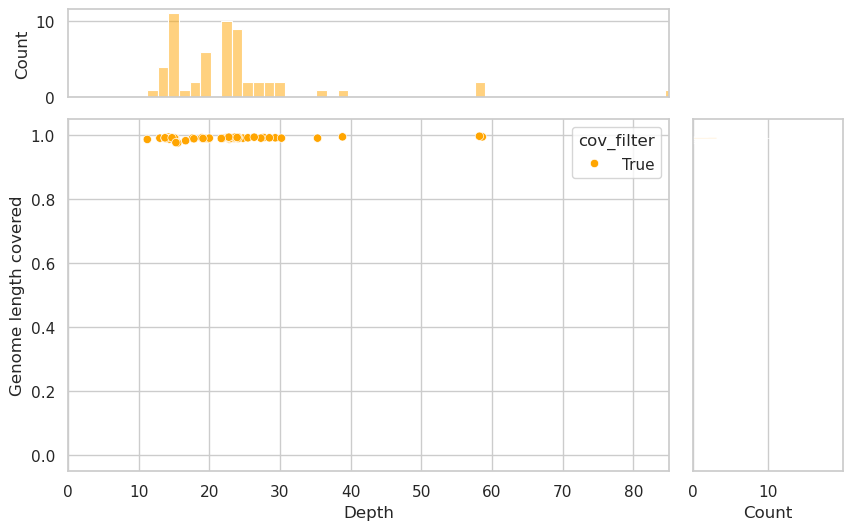

In [15]:
# set plot style
sns.set(style='whitegrid')
plt.rcParams.update({'font.size': 16})

# figure & grid layout
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.065, hspace=0.1) # adjust so nothing overlaps

### COVERAGE ###
# Top histogram (cov_chrA)
ax_top = plt.subplot(gs[0, 0])
sns.histplot(data=df_coverage, x='cov_A', bins=50, ax=ax_top, legend=False, hue='cov_filter',
                palette={True: 'orange', False: 'darkgrey'})
ax_top.set_xlim(0, 85)
#ax_top.set_xscale('log')
ax_top.set_ylabel('Count')
ax_top.set_xticks([])
ax_top.set_xlabel('')
ax_top.tick_params(bottom=False)

### FRACTION ###
# Right histogram (frac_cov_chrA)
ax_right = plt.subplot(gs[1, 1])
sns.histplot(data=df_coverage, y='cov_len_A', bins=50, ax=ax_right, legend=False, hue='cov_filter',
                palette={True: 'orange', False: 'darkgrey'})
ax_right.set_ylim(-0.05, 1.05)
ax_right.set_ylabel('')
ax_right.set_yticks([])
ax_right.set_xlabel('Count')
ax_right.tick_params(left=False)

### SCATTER PLOT ###
ax_main = plt.subplot(gs[1, 0])
sns.scatterplot(data=df_coverage, x='cov_A', y='cov_len_A', ax=ax_main, hue='cov_filter',
                palette={True: 'orange', False: 'darkgrey'})
ax_main.set_xlim(0, 85)
ax_main.set_ylim(-0.05, 1.05)
ax_main.set_xlabel('Depth')
ax_main.set_ylabel('Genome length covered')
#fig.suptitle('Correlation between Coverage Depth and Genome Coverage (Panthera tigris)', fontsize=14)
os.mkdir(f"{path_prefix}/megaFauna/sa_megafauna/results/{species}/coverage/")
plt.savefig(f"{path_prefix}/megaFauna/sa_megafauna/results/{species}/coverage/Correlation_Coverage_Depth_and_Genome_Coverage_{species}.png")
plt.show()

In [16]:
print(df_coverage['cov_A'].describe())
print(df_coverage['cov_A'].isna().sum())

count    57.000000
mean     23.375737
std      12.301997
min      11.208000
25%      15.259000
50%      22.614000
75%      24.066000
max      86.003000
Name: cov_A, dtype: float64
0


In [17]:
df_coverage_filtered.sort_values(by=["cov_A"], ascending=False).head(20)

,IND_ID,length_A,sequenced_A,len_covered_raw_A,cov_A,cov_len_A,SEX,length_X,sequenced_X,len_covered_raw_X,cov_X,cov_len_X,rel_X_cov,gSEX,length_Y,sequenced_Y,len_covered_raw_Y,cov_Y,cov_len_Y,cov_filter
0,SAMD00195598,3199039572,2.741918e+11,3188148349,86.003,0.997,Unknown,181417049,8.309614e+09,180358920,46.073,0.994,0.536,M,15906473,1.061222e+09,14945063,71.008,0.940,True
22,SAMN14648705,3199039572,1.865430e+11,3181567397,58.632,0.995,F,181417049,1.035490e+10,180457139,57.382,0.995,0.979,F,15906473,4.588653e+06,564366,8.131,0.035,True
23,SAMN28571076,3199039572,1.857097e+11,3189770703,58.220,0.997,M,181417049,5.286923e+09,180338323,29.317,0.994,0.504,M,15906473,5.072497e+08,14944414,33.942,0.940,True
28,SAMN28571083,3199039572,1.236285e+11,3183388336,38.836,0.995,M,181417049,3.554527e+09,179997233,19.748,0.992,0.508,M,15906473,3.780341e+08,14934693,25.312,0.939,True
21,SAMN03448703,3199039572,1.119662e+11,3171347487,35.306,0.991,Unknown,181417049,6.171701e+09,180034248,34.281,0.992,0.971,F,15906473,3.386005e+06,694965,4.872,0.044,True
15,SAMEA120295694,3199039572,9.569170e+10,3169299721,30.193,0.991,Unknown,181417049,5.345755e+09,179897735,29.716,0.992,0.984,F,15906473,2.374197e+06,447932,5.300,0.028,True
5,SAMEA120295683,3199039572,9.305367e+10,3173269435,29.324,0.992,Unknown,181417049,5.175474e+09,180327171,28.700,0.994,0.979,F,15906473,2.002760e+06,224837,8.908,0.014,True
17,SAMEA120295697,3199039572,9.040102e+10,3173342118,28.488,0.992,Unknown,181417049,5.025005e+09,180406255,27.854,0.994,0.978,F,15906473,1.846074e+06,205583,8.980,0.013,True
8,SAMEA120295686,3199039572,8.795303e+10,3178077936,27.675,0.993,Unknown,181417049,4.835845e+09,180199652,26.836,0.993,0.970,F,15906473,2.059677e+06,398473,5.169,0.025,True
10,SAMEA120295688,3199039572,8.649464e+10,3170286300,27.283,0.991,Unknown,181417049,4.799562e+09,180155653,26.641,0.993,0.976,F,15906473,1.761386e+06,212734,8.280,0.013,True


In [61]:
df_coverage_filtered.to_csv("df_coverage_filtered.csv", index=False)

In [9]:
genus_list      = ["Boselaphus_tragocamelus"]
data            = pd.concat([pd.read_table(f) for f in [f"/{path_prefix}/megaFauna/sa_megafauna/metadata/samples_{genus}.txt" for genus in genus_list]], ignore_index=True) # add all SRR accession from genus_list in a single data frame
ref_folders     = sorted(set(data.REFERENCE_FOLDER)) # list of references needed to map the SRR accessions

for ref_folder in ref_folders:
    sub_data = data[data.REFERENCE_FOLDER == ref_folder]
    sub_data.to_csv(f"/{path_prefix}/megaFauna/sa_megafauna/metadata/samples_{ref_folder}.txt", sep="\t", index=False)


PermissionError: [Errno 13] Permission denied: '//home/lakrids/GenomeDK/megaFauna/sa_megafauna/metadata/samples_Tragelaphus_eurycerus_isaaci.txt'